# 1. Giới thiệu

Trong notebook này, dữ liệu [Vietnamese Sentiment Analysis (VSFC)](https://nlp.uit.edu.vn/datasets#h.p_4Brw8L-cbfTe) sẽ được hướng dẫn chuẩn bị. Nhiệm vụ của bạn:
- Xử lý văn bản (preprocessing)
- Biểu diễn dữ liệu (BoW hoặc TF-IDF)
- Xây dựng mô hình
- Đánh giá và phân tích kết quả

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# 2. Load dữ liệu VSFC

## 2.1. Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import os

## 2.2. Tải dataset

* Bước 1: Tải dữ liệu từ [Google Drive](https://drive.google.com/drive/folders/1xclbjHHK58zk2X6iqbvMPS2rcy9y9E0X) của team UIT.
* Bước 2: Upload lên Google Colab theo cấu trúc
```
train/
  sents.txt
  sentiments.txt
test/
  sents.txt
  sentiments.txt
```

Lưu ý: tạo folder rồi up từng file txt lên sẽ dễ hơn.


## 2.3. Hàm load dữ liệu

In [ ]:
def load_vsfc(path):
    texts = []
    labels = []

    with open(os.path.join(path, "sents.txt"), encoding="utf-8") as f:
        texts = f.readlines()

    with open(os.path.join(path, "sentiments.txt"), encoding="utf-8") as f:
        labels = f.readlines()

    # strip newline
    texts = [t.strip() for t in texts]
    labels = [l.strip() for l in labels]

    return texts, labels

## 2.4. Load train/test


Lưu ý: tập train luôn có kích thước lớn hơn nha :)

In [ ]:
train_texts, train_labels = load_vsfc("./train")
test_texts, test_labels = load_vsfc("./test")

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))

Train size: 11426
Test size: 3166


## 2.5. Tạo DataFrame

In [ ]:
train_df = pd.DataFrame({
    "text": train_texts,
    "label": train_labels
})

test_df = pd.DataFrame({
    "text": test_texts,
    "label": test_labels
})

train_df.head()

,text,label
0,slide giáo trình đầy đủ .,2
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2
2,đi học đầy đủ full điểm chuyên cần .,0
3,chưa áp dụng công nghệ thông tin và các thiết ...,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2


## 2.6. Chuẩn hóa label

In [ ]:
# mapping label
label_map = {
    "0": "negative",
    "1": "neutral",
    "2": "positive"
}

train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

## 2.7. Kiểm tra phân bố dữ liệu

In [ ]:
print("Train distribution:")
print(train_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Train distribution:
label
positive    5643
negative    5325
neutral      458
Name: count, dtype: int64

Test distribution:
label
positive    1590
negative    1409
neutral      167
Name: count, dtype: int64


## 2.8. Xem 1 vài mẫu dữ liệu

In [ ]:
train_df.sample(5)

,text,label
4278,em nghỉ nên biên soạn lại .,negative
1968,"thầy ơi giảng bài tự tin lên thầy , nói nhiều ...",negative
4695,thầy giảng thường cắt ngang mạch cảm hứng bằng...,negative
4461,"dạy hơi nhanh à nha , tiết bài tập chưa tốt .",negative
764,"hướng dẫn rất tận tình , trình bày hướng dẫn r...",positive


## 2.9. Visualization

In [ ]:
train_df["length"] = train_df["text"].apply(lambda x: len(x.split()))

print("Mean length:", train_df["length"].mean())
print("Max length:", train_df["length"].max())
print("Min length:", train_df["length"].min())

Mean length: 14.308769473131454
Max length: 159
Min length: 2


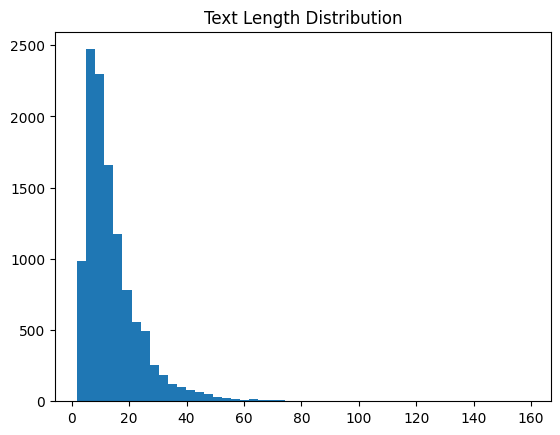

In [ ]:
import matplotlib.pyplot as plt

plt.hist(train_df["length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

# 3. Xây dựng vector đặc trưng (dựa trên Word2Vec)


Truy cập repo [PhoW2V](https://github.com/datquocnguyen/PhoW2V?tab=readme-ov-file) -> Chọn "Embedding size = 100" -> click vào mirror (GG drive) -> download ```word2vec_vi_words_100dims.zip```


* Cách 1. Unzip local -> up file txt lên Google Colab
* Cách 2. Upload file zip lên Google Colab -> mở Terminal của Google Colab -> gõ ```unzip word2vec_vi_words_100dims.zip```

-> Mục tiêu: nhìn thấy file ```word2vec_vi_words_100dims.txt```



## 3.1. Load PhoW2V


In [ ]:
import numpy as np

def load_phow2v(path, dim=100):
    embedding = {}

    with open(path, encoding="utf-8") as f:
        next(f)  # bỏ dòng metadata

        for line in f:
            parts = line.strip().split()

            # vector = 100 phần tử cuối
            vector = np.array(parts[-dim:], dtype=float)

            # word = phần còn lại
            word = " ".join(parts[:-dim])

            # ⚠️ convert space → underscore để match underthesea
            word = word.replace(" ", "_")

            embedding[word] = vector

    return embedding

In [ ]:
# Load embedding (100 chiều)
embedding = load_phow2v("/content/word2vec_vi_words_100dims.txt")

print("Vocab size:", len(embedding))

# Test thử
print("Vector size:", len(next(iter(embedding.values()))))

Vocab size: 1585595
Vector size: 100


## 3.2. Preprocessing

In [ ]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.3 MB/s eta 0:00:00


In [ ]:
import re
from underthesea import word_tokenize

def preprocess(text):
    # lowercase
    text = text.lower()

    # remove ký tự đặc biệt
    text = re.sub(r"[^a-zA-ZÀ-ỹ0-9\s]", " ", text)

    # remove khoảng trắng dư
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize tiếng Việt
    text = word_tokenize(text, format="text")

    return text

In [ ]:
train_df["processed"] = train_df["text"].apply(preprocess)
test_df["processed"] = test_df["text"].apply(preprocess)

train_df[["text", "processed"]].head()

,text,processed
0,slide giáo trình đầy đủ .,slide giáo_trình đầy_đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy_đủ full_điểm chuyên cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...


## 3.3. Sentence Embedding

In [ ]:
def sentence_vector(text, embedding, dim=100):
    words = text.split()

    vectors = []

    for w in words:
        if w in embedding:
            vectors.append(embedding[w])

    # Nếu không có từ nào match
    if len(vectors) == 0:
        return np.zeros(dim)

    return np.mean(vectors, axis=0)

## 3.4. Build Feature Matrix

In [ ]:
X_train = np.array([
    sentence_vector(text, embedding)
    for text in train_df["processed"]
])

X_test = np.array([
    sentence_vector(text, embedding)
    for text in test_df["processed"]
])

y_train = train_df["label"]
y_test = test_df["label"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (11426, 100)
X_test shape: (3166, 100)


## 3.5. Kiểm tra coverage

- Coverage cao → embedding tốt  
- Coverage thấp → nhiều từ không được biểu diễn  

Đây là yếu tố rất quan trọng với Word2Vec


In [ ]:
def coverage(texts, embedding):
    total = 0
    found = 0

    for text in texts:
        for w in text.split():
            total += 1
            if w in embedding:
                found += 1

    return found / total

In [ ]:
cov = coverage(train_df["processed"], embedding)

print("Embedding coverage:", cov)

Embedding coverage: 0.9811234181571243


# 4. Xây dựng mô hình

## 4.1. Modeling

In [ ]:
# TODO:
# - Train model (Logistic Regression / SVM)


## 4.2. Prediction

In [ ]:
# TODO:
# - Predict trên tập test


## 4.3. Evaluation

In [ ]:
# TODO:
# - Accuracy
# - Classification report
# - Confusion matrix


## 4.4. Error Analysis

In [ ]:
# TODO:
# - Tìm các sample dự đoán sai
# - Phân tích nguyên nhân


# 5. Thảo luận
1. PhoW2V có cải thiện so với TF-IDF không?
2. Average embedding có hạn chế gì?
3. Coverage ảnh hưởng thế nào đến kết quả?
4. Bạn nghĩ phiên bản 300 dims có tốt hơn không?